# EDM Cascaded Diffusion, MRI Sampling Notebook


## 1. Environment Setup

In [1]:
import sys, os, glob, pickle, math, json

import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from IPython.display import display

# ── Paths ─────────────────────────────────────────────────────────────────────
# Resolve PROJECT_ROOT robustly: prefer an env override, then walk up from the
# notebook's cwd looking for the repo's marker dirs (edm_repo/ + scripts/),
# then fall back to known locations.
_CANDIDATES = [
    os.environ.get('CASCADE_PROJECT_ROOT'),
    '/home2/wzr8sn/Work/cascade_diffusion_mri']

def _looks_like_root(p):
    return p and os.path.isdir(os.path.join(p, 'edm_repo')) \
             and os.path.isdir(os.path.join(p, 'scripts'))

PROJECT_ROOT = None
# 1) walk up from cwd
_d = os.getcwd()
for _ in range(4):
    if _looks_like_root(_d):
        PROJECT_ROOT = _d
        break
    _d = os.path.dirname(_d)
# 2) explicit candidates
if PROJECT_ROOT is None:
    for _c in _CANDIDATES:
        if _looks_like_root(_c):
            PROJECT_ROOT = _c
            break
if PROJECT_ROOT is None:
    raise RuntimeError(
        "Could not locate project root (a dir containing edm_repo/ and scripts/). "
        "Set the CASCADE_PROJECT_ROOT env var or edit _CANDIDATES above."
    )

EDM_PATH     = os.path.join(PROJECT_ROOT, 'edm_repo')
SCRIPTS_PATH = os.path.join(PROJECT_ROOT, 'scripts')

for p in [EDM_PATH, SCRIPTS_PATH]:
    if p not in sys.path:
        sys.path.insert(0, p)

print(f"Project root : {PROJECT_ROOT}")
print(f"EDM repo     : {EDM_PATH}")
print(f"Scripts      : {SCRIPTS_PATH}")


Project root : /CBIG-Standard-ECE/Sahil/mri_cascaded_diffusion
EDM repo     : /CBIG-Standard-ECE/Sahil/mri_cascaded_diffusion/edm_repo
Scripts      : /CBIG-Standard-ECE/Sahil/mri_cascaded_diffusion/scripts


## 2. Configuration

In [4]:



GPU_ID = 2     
device = torch.device(f'cuda:{GPU_ID}' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

# ── Checkpoint paths (set to None for auto-detect)
base_ckpt   = None   
sr_384_ckpt = None   # e.g. "checkpoints/edm_mri_sr_384/network-snapshot-002637.pkl"
#'/CBIG-Standard-ECE/Sahil/mri_cascaded_diffusion/checkpoints/edm_mri_sr_384/network-snapshot-003089.pkl'
#'/CBIG-Standard-ECE/Sahil/mri_cascaded_diffusion/checkpoints/edm_mri_base_96/network-snapshot-027597.pkl'
sr_384_ckpt = "/CBIG-Standard-ECE/Sahil/mri_cascaded_diffusion/checkpoints/edm_mri_sr_384_small/network-snapshot-002788.pkl"
def find_latest_pkl(glob_pattern):
    """Find the most recent .pkl file matching a glob pattern under PROJECT_ROOT."""
    hits = sorted(glob.glob(os.path.join(PROJECT_ROOT, glob_pattern)))
    return hits[-1] if hits else None

if base_ckpt is None:
    base_ckpt = find_latest_pkl("checkpoints/edm_mri_base_96/network-snapshot-*.pkl")
    print(f"Auto-detected base ckpt   : {base_ckpt}" if base_ckpt else
          "⚠️  No base checkpoint found — set base_ckpt manually.")

if sr_384_ckpt is None:
    sr_384_ckpt = find_latest_pkl("checkpoints/edm_mri_sr_384/network-snapshot-*.pkl")
    print(f"Auto-detected SR-384 ckpt : {sr_384_ckpt}" if sr_384_ckpt else
          "ℹ️  No SR-384 checkpoint — only Stage 1 will run.")

NUM_SAMPLES = 8        # total samples to generate
BATCH_SIZE  = 4        # images per GPU batch (reduce if OOM)
NUM_STEPS   = 18     # Heun steps per stage (EDM default)
SIGMA_MIN   = 0.001
SIGMA_MAX   = 80.0
RHO         = 7
SEED        = 42      # reproducibility; set to None for random

# ── CDM conditioning augmentation at inference ─
# During training S to U[0,300] forward-diffusion blur is applied to low_res.
# At inference: use s=0 (no blur) for cleanest conditioning, or set to
# a small positive value to match training distribution.
COND_AUG_TIMESTEP = 0  

if SEED is not None:
    torch.manual_seed(SEED)
    np.random.seed(SEED)

stages = ['base']
if sr_384_ckpt:
    stages.append('sr_384')
print(f"\nCascade stages : {' → '.join(stages)}")
print(f"Samples        : {NUM_SAMPLES}  |  Steps/stage : {NUM_STEPS}  |  Batch : {BATCH_SIZE}")


Device: cuda:2
Auto-detected base ckpt   : /CBIG-Standard-ECE/Sahil/mri_cascaded_diffusion/checkpoints/edm_mri_base_96/network-snapshot-028350.pkl

Cascade stages : base → sr_384
Samples        : 8  |  Steps/stage : 18  |  Batch : 4


## 3. EDM Heun Sampler

Direct translation of Algorithm 2 from Karras et al. (2022).
Works for **both** the base `EDMPrecond` and the SR `EDMSRPrecond` —
just pass `low_res=...` in `model_kwargs` for the SR stage.

In [5]:
@torch.no_grad()
def edm_heun_sampler(
    net, latents,
    num_steps=18, sigma_min=0.002, sigma_max=80.0, rho=7,
    S_churn=0, S_min=0, S_max=float('inf'), S_noise=1,
    verbose=True,
    **model_kwargs,
):
    """
    Heun 2nd-order ODE sampler (deterministic by default).

    Parameters
    ----------
    net        : EDMPrecond or EDMSRPrecond model (already on device, eval mode)
    latents    : (B, C, H, W) initial noise tensor on device
    num_steps  : number of Heun steps
    model_kwargs : extra kwargs forwarded to net() on every call.
                   Pass  low_res=<tensor>  for the SR stage.

    Returns
    -------
    x : (B, C, H, W) float32 denoised output in [-1, 1]
    """
    sigma_min = max(sigma_min, net.sigma_min)
    sigma_max = min(sigma_max, net.sigma_max)

    # ρ-schedule: t_0 = σ_max, t_T = σ_min
    step_indices = torch.arange(num_steps, dtype=torch.float64, device=latents.device)
    t_steps = (
        sigma_max ** (1 / rho)
        + step_indices / (num_steps - 1)
        * (sigma_min ** (1 / rho) - sigma_max ** (1 / rho))
    ) ** rho
    t_steps = torch.cat([net.round_sigma(t_steps), torch.zeros_like(t_steps[:1])])

    x_next = latents.to(torch.float64) * t_steps[0]

    for i, (t_cur, t_next) in enumerate(zip(t_steps[:-1], t_steps[1:])):
        x_cur = x_next

        # Optional stochastic noise injection
        gamma = (
            min(S_churn / num_steps, math.sqrt(2) - 1)
            if S_min <= float(t_cur) <= S_max else 0.0
        )
        t_hat = net.round_sigma(t_cur + gamma * t_cur)
        x_hat = x_cur + (t_hat**2 - t_cur**2).sqrt() * S_noise * torch.randn_like(x_cur)

        # Euler step
        denoised = net(
            x_hat.to(torch.float32), t_hat.to(torch.float32), **model_kwargs
        ).to(torch.float64)
        d_cur = (x_hat - denoised) / t_hat
        x_next = x_hat + (t_next - t_hat) * d_cur

        # 2nd-order Heun correction
        if i < num_steps - 1:
            denoised = net(
                x_next.to(torch.float32), t_next.to(torch.float32), **model_kwargs
            ).to(torch.float64)
            d_prime = (x_next - denoised) / t_next
            x_next = x_hat + (t_next - t_hat) * (0.5 * d_cur + 0.5 * d_prime)

        if verbose and (i % 6 == 0 or i == num_steps - 1):
            print(f"    step {i+1:2d}/{num_steps}  σ {float(t_cur):.4f} → {float(t_next):.4f}")

    return x_next.to(torch.float32)


## 4. CDM Conditioning Augmentation 



In [6]:
def _linear_beta_schedule(num_timesteps=1000):
    scale = 1000 / num_timesteps
    betas = np.linspace(scale * 0.0001, scale * 0.02, num_timesteps, dtype=np.float64)
    alphas_cumprod = np.cumprod(1.0 - betas)
    sqrt_ac  = torch.from_numpy(np.sqrt(alphas_cumprod)).float()
    sqrt_1m  = torch.from_numpy(np.sqrt(1.0 - alphas_cumprod)).float()
    return sqrt_ac, sqrt_1m

_sqrt_ac, _sqrt_1m = _linear_beta_schedule()

def apply_cond_aug(low_res: torch.Tensor, s: int) -> torch.Tensor:
    """
    Apply CDM §4.2 conditioning augmentation to low_res at timestep s.

    Parameters
    ----------
    low_res : (B, 2, 96, 96) on CPU or GPU
    s       : augmentation timestep (0 = no-op, max 999)

    Returns
    -------
    (B, 2, 96, 96) blurred/noised low_res
    """
    if s <= 0:
        return low_res
    sqrt_alpha = _sqrt_ac[s - 1].to(low_res.device)
    sqrt_1m    = _sqrt_1m[s - 1].to(low_res.device)
    return sqrt_alpha * low_res + sqrt_1m * torch.randn_like(low_res)

print(f"CDM cond-aug timestep at inference : s={COND_AUG_TIMESTEP}")


CDM cond-aug timestep at inference : s=0


## 5. Visualisation Helpers

In [7]:
def mri_magnitude(x: torch.Tensor) -> np.ndarray:
    """
    Convert 2-channel (Re, Im) MRI tensor to magnitude image.

    Parameters
    ----------
    x : (B, 2, H, W) in [-1, 1]

    Returns
    -------
    mag : (B, H, W) float32 in [0, 1]  — magnitude, normalised per image
    """
    re, im = x[:, 0], x[:, 1]   # each (B, H, W)
    mag = torch.sqrt(re**2 + im**2).float().cpu()
    # Normalise each image independently to [0, 1] for display
    b = mag.shape[0]
    mag_min = mag.view(b, -1).min(dim=1).values.view(b, 1, 1)
    mag_max = mag.view(b, -1).max(dim=1).values.view(b, 1, 1)
    mag = (mag - mag_min) / (mag_max - mag_min + 1e-8)
    return mag.numpy()  # (B, H, W)


def show_magnitude_grid(
    mag_np: np.ndarray,
    title: str = "",
    nrow: int = 8,
    cmap: str = "gray",
    figsize=None,
):
    """
    Display a grid of magnitude MRI images.

    Parameters
    ----------
    mag_np : (N, H, W) numpy array in [0, 1]
    """
    n    = len(mag_np)
    ncol = min(nrow, n)
    nrows_plot = math.ceil(n / ncol)

    if figsize is None:
        figsize = (ncol * 1.8, nrows_plot * 1.8)

    fig, axes = plt.subplots(nrows_plot, ncol, figsize=figsize)
    axes = np.array(axes).reshape(nrows_plot, ncol)

    for i in range(nrows_plot):
        for j in range(ncol):
            ax = axes[i, j]
            ax.axis("off")
            idx = i * ncol + j
            if idx < n:
                ax.imshow(mag_np[idx], cmap=cmap, interpolation="bilinear")

    if title:
        fig.suptitle(title, fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()


def show_cascade_comparison(results: dict, n_show: int = 6, cmap: str = "gray"):
    """
    Side-by-side cascade comparison: base (96) | NN-up (384) | SR (384).

    Parameters
    ----------
    results : OrderedDict  stage_label → (B, 2, H, W) tensor in [-1, 1]
    """
    stage_names = list(results.keys())
    n_stages    = len(stage_names)
    n_show      = min(n_show, results[stage_names[0]].shape[0])

    fig, axes = plt.subplots(n_show, n_stages, figsize=(n_stages * 2.4, n_show * 2.4))
    if n_show == 1:
        axes = axes[np.newaxis, :]
    if n_stages == 1:
        axes = axes[:, np.newaxis]

    for col, name in enumerate(stage_names):
        mag = mri_magnitude(results[name][:n_show])     # (n_show, H, W)
        axes[0, col].set_title(name, fontsize=10, fontweight="bold")
        for row in range(n_show):
            axes[row, col].imshow(mag[row], cmap=cmap, interpolation="bilinear",vmax=0.7, vmin=0.0)
            axes[row, col].axis("off")

    fig.suptitle("EDM MRI Cascaded Diffusion — Magnitude Images", fontsize=13,
                 fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.show()


## 6. Load Models

In [8]:
# Import EDMSRPrecond so pickle can reconstruct SR model checkpoints
from edm_sr_model import EDMSRPrecond                   # noqa — needed for pickle
from training.networks import EDMPrecond                 # noqa — needed for pickle

models = {}

# ── Base model (96×96, 2ch) ───────────────────────────────────────────────────
assert base_ckpt is not None, "No base checkpoint found — set base_ckpt manually!"
print(f"Loading base model:\n  {base_ckpt}")
with open(base_ckpt, "rb") as f:
    data = pickle.load(f)
model_base = data["ema"].to(device).eval()
models["base"] = model_base
n_p = sum(p.numel() for p in model_base.parameters())
print(f"  ✓  {n_p:,} params")
print(f"     img_resolution = {model_base.img_resolution}")
print(f"     img_channels   = {model_base.img_channels}")
del data
torch.cuda.empty_cache()

# ── SR model (96 → 384, 2ch) ──────────────────────────────────────────────────
if sr_384_ckpt:
    print(f"\nLoading SR-384 model:\n  {sr_384_ckpt}")
    with open(sr_384_ckpt, "rb") as f:
        data = pickle.load(f)
    model_sr = data["ema"].to(device).eval()
    models["sr_384"] = model_sr
    n_p = sum(p.numel() for p in model_sr.parameters())
    print(f"  ✓  {n_p:,} params")
    print(f"     img_resolution = {model_sr.img_resolution}")
    print(f"     img_channels   = {model_sr.img_channels}")
    del data
    torch.cuda.empty_cache()
else:
    model_sr = None
    print("ℹ️  No SR-384 model — will run base stage only.")

print(f"\nLoaded stages: {list(models.keys())}")


Loading base model:
  /CBIG-Standard-ECE/Sahil/mri_cascaded_diffusion/checkpoints/edm_mri_base_96/network-snapshot-028350.pkl
  ✓  60,483,714 params
     img_resolution = 96
     img_channels   = 2

Loading SR-384 model:
  /CBIG-Standard-ECE/Sahil/mri_cascaded_diffusion/checkpoints/edm_mri_sr_384_small/network-snapshot-002788.pkl
  ✓  9,665,858 params
     img_resolution = 384
     img_channels   = 2

Loaded stages: ['base', 'sr_384']


## 7. Stage 1 — Base Model (96×96)

Pure Gaussian noise → denoised 2-channel MRI at 96×96.
No conditioning input needed.

In [9]:
print(f"Generating {NUM_SAMPLES} base samples  ({model_base.img_resolution}×{model_base.img_resolution}, "
      f"{model_base.img_channels}ch, {NUM_STEPS} Heun steps)…")

all_base = []
n_done   = 0

while n_done < NUM_SAMPLES:
    bs = min(BATCH_SIZE, NUM_SAMPLES - n_done)
    print(f"\n  Batch {n_done+1}–{n_done+bs} / {NUM_SAMPLES}")

    latents = torch.randn(
        [bs, model_base.img_channels,
         model_base.img_resolution, model_base.img_resolution],
        device=device,
    )
    samples = edm_heun_sampler(
        model_base, latents,
        num_steps=NUM_STEPS,
        sigma_min=SIGMA_MIN, sigma_max=SIGMA_MAX, rho=RHO,
    )                                              # (B, 2, 96, 96) float32
    all_base.append(samples.cpu())
    n_done += bs

base_96 = torch.cat(all_base, dim=0)              # (N, 2, 96, 96)
print(f"\n✓ Base samples: {tuple(base_96.shape)}")
print(f"  Real   channel  — min={base_96[:,0].min():.3f}  max={base_96[:,0].max():.3f}")
print(f"  Imag   channel  — min={base_96[:,1].min():.3f}  max={base_96[:,1].max():.3f}")


Generating 8 base samples  (96×96, 2ch, 18 Heun steps)…

  Batch 1–4 / 8
    step  1/18  σ 80.0000 → 57.0723
    step  7/18  σ 7.8245 → 4.8643
    step 13/18  σ 0.2351 → 0.1054
    step 18/18  σ 0.0010 → 0.0000

  Batch 5–8 / 8
    step  1/18  σ 80.0000 → 57.0723
    step  7/18  σ 7.8245 → 4.8643
    step 13/18  σ 0.2351 → 0.1054
    step 18/18  σ 0.0010 → 0.0000

✓ Base samples: (8, 2, 96, 96)
  Real   channel  — min=-0.715  max=0.683
  Imag   channel  — min=-0.682  max=0.843


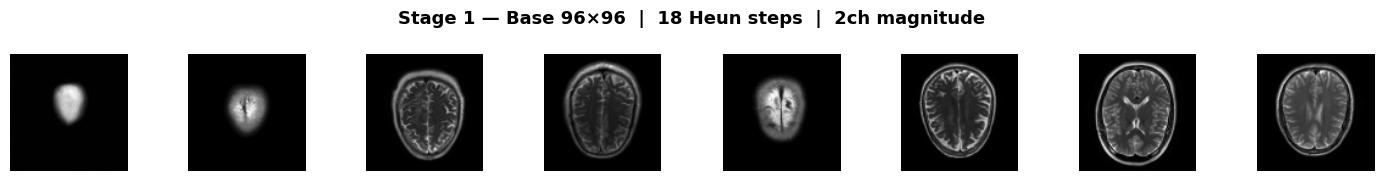

In [10]:
# Display magnitude images from Stage 1
show_magnitude_grid(
    mri_magnitude(base_96),
    title=f"Stage 1 — Base 96×96  |  {NUM_STEPS} Heun steps  |  2ch magnitude",
    nrow=min(8, NUM_SAMPLES),
)


## 8. Stage 2 — Super-Resolution 96 → 384

The `EDMSRPrecond` model receives a concatenated 4-channel input:

```
[c_in(σ) · x_noisy  |  bilinear_upsample(low_res)]   (B, 4, 384, 384)
```

`low_res` is the 96×96 base-model output. Optionally apply CDM conditioning
augmentation (`COND_AUG_TIMESTEP > 0`) to match training distribution.

Running SR cascade: 96×96 → 384×384
  CDM cond-aug timestep : s=0  (0 = clean)
  Heun steps            : 18

  Batch 1–4 / 8
    step  1/18  σ 80.0000 → 57.0723
    step  7/18  σ 7.8245 → 4.8643
    step 13/18  σ 0.2351 → 0.1054
    step 18/18  σ 0.0010 → 0.0000

  Batch 5–8 / 8
    step  1/18  σ 80.0000 → 57.0723
    step  7/18  σ 7.8245 → 4.8643
    step 13/18  σ 0.2351 → 0.1054
    step 18/18  σ 0.0010 → 0.0000

✓ SR samples: (8, 2, 384, 384)
  Real  min=-0.740  max=0.841
  Imag  min=-0.704  max=0.868


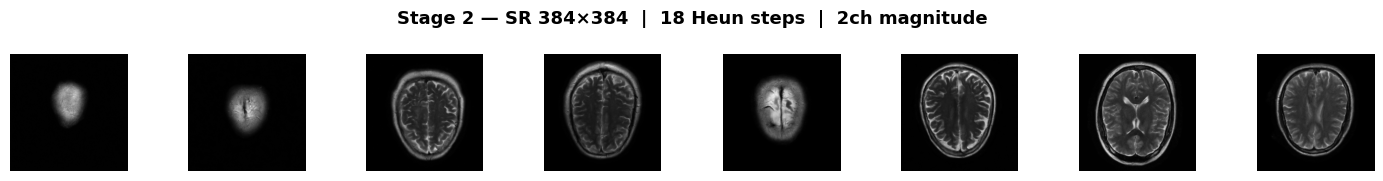

In [11]:
if model_sr is not None:
    print(f"Running SR cascade: 96×96 → {model_sr.img_resolution}×{model_sr.img_resolution}")
    print(f"  CDM cond-aug timestep : s={COND_AUG_TIMESTEP}  (0 = clean)")
    print(f"  Heun steps            : {NUM_STEPS}")

    all_sr = []
    n_done = 0

    while n_done < NUM_SAMPLES:
        bs = min(BATCH_SIZE, NUM_SAMPLES - n_done)
        print(f"\n  Batch {n_done+1}–{n_done+bs} / {NUM_SAMPLES}")

        # ── Conditioning input ────────────────────────────────────────────
        # base_96[n_done:n_done+bs] is (bs, 2, 96, 96)
        low_res = base_96[n_done : n_done + bs].to(device)          # (bs, 2, 96, 96)

        # Apply CDM conditioning augmentation (s=0 → no-op)
        low_res = apply_cond_aug(low_res, s=COND_AUG_TIMESTEP)

        # ── Sample HR from noise, conditioned on low_res ──────────────────
        latents = torch.randn(
            [bs, model_sr.img_channels,
             model_sr.img_resolution, model_sr.img_resolution],
            device=device,
        )
        # EDMSRPrecond.forward() handles bilinear upsampling of low_res internally
        samples = edm_heun_sampler(
            model_sr, latents,
            num_steps=NUM_STEPS,
            sigma_min=SIGMA_MIN, sigma_max=SIGMA_MAX, rho=RHO,
            low_res=low_res,   # ← conditioning; model bilinearly upsamples 96→384
        )                                              # (bs, 2, 384, 384) float32
        all_sr.append(samples.cpu())
        n_done += bs

    sr_384 = torch.cat(all_sr, dim=0)                 # (N, 2, 384, 384)
    print(f"\n✓ SR samples: {tuple(sr_384.shape)}")
    print(f"  Real  min={sr_384[:,0].min():.3f}  max={sr_384[:,0].max():.3f}")
    print(f"  Imag  min={sr_384[:,1].min():.3f}  max={sr_384[:,1].max():.3f}")

    # ── Display ───────────────────────────────────────────────────────────
    show_magnitude_grid(
        mri_magnitude(sr_384),
        title=f"Stage 2 — SR 384×384  |  {NUM_STEPS} Heun steps  |  2ch magnitude",
        nrow=min(8, NUM_SAMPLES),
    )
else:
    sr_384 = None
    print("ℹ️  SR-384 model not loaded — skipping Stage 2.")


## 8b. SR 384×384 — Magnitude with vmax = 0.6

Visualise the upsampled / super-resolved images with a fixed display ceiling
of **vmax = 0.6** so that contrast differences are easier to compare across samples.

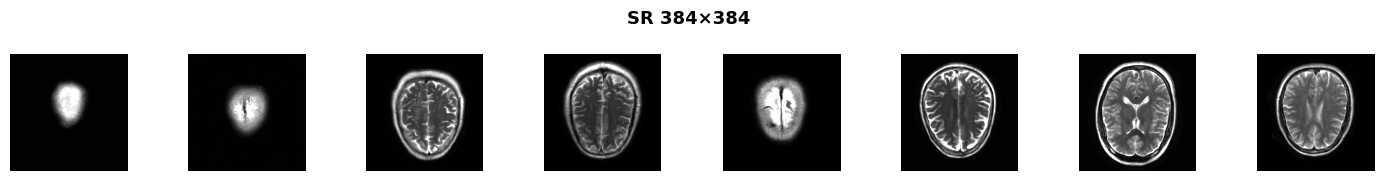

In [12]:
if sr_384 is not None:
    mag_sr = mri_magnitude(sr_384)   # (N, 384, 384) in [0, 1]
    n      = len(mag_sr)
    ncol   = min(8, n)
    nrows  = math.ceil(n / ncol)

    fig, axes = plt.subplots(nrows, ncol,
                             figsize=(ncol * 1.8, nrows * 1.8))
    axes = np.array(axes).reshape(nrows, ncol)

    for i in range(nrows):
        for j in range(ncol):
            ax  = axes[i, j]
            ax.axis("off")
            idx = i * ncol + j
            if idx < n:
                ax.imshow(mag_sr[idx], cmap="gray",
                          interpolation="bilinear",
                          vmin=0.0, vmax=0.6)

    fig.suptitle(
        f"SR 384×384 ",
        fontsize=13, fontweight="bold"
    )
    plt.tight_layout()
    plt.show()
else:
    print("ℹ️  sr_384 is None — run Stage 2 first.")


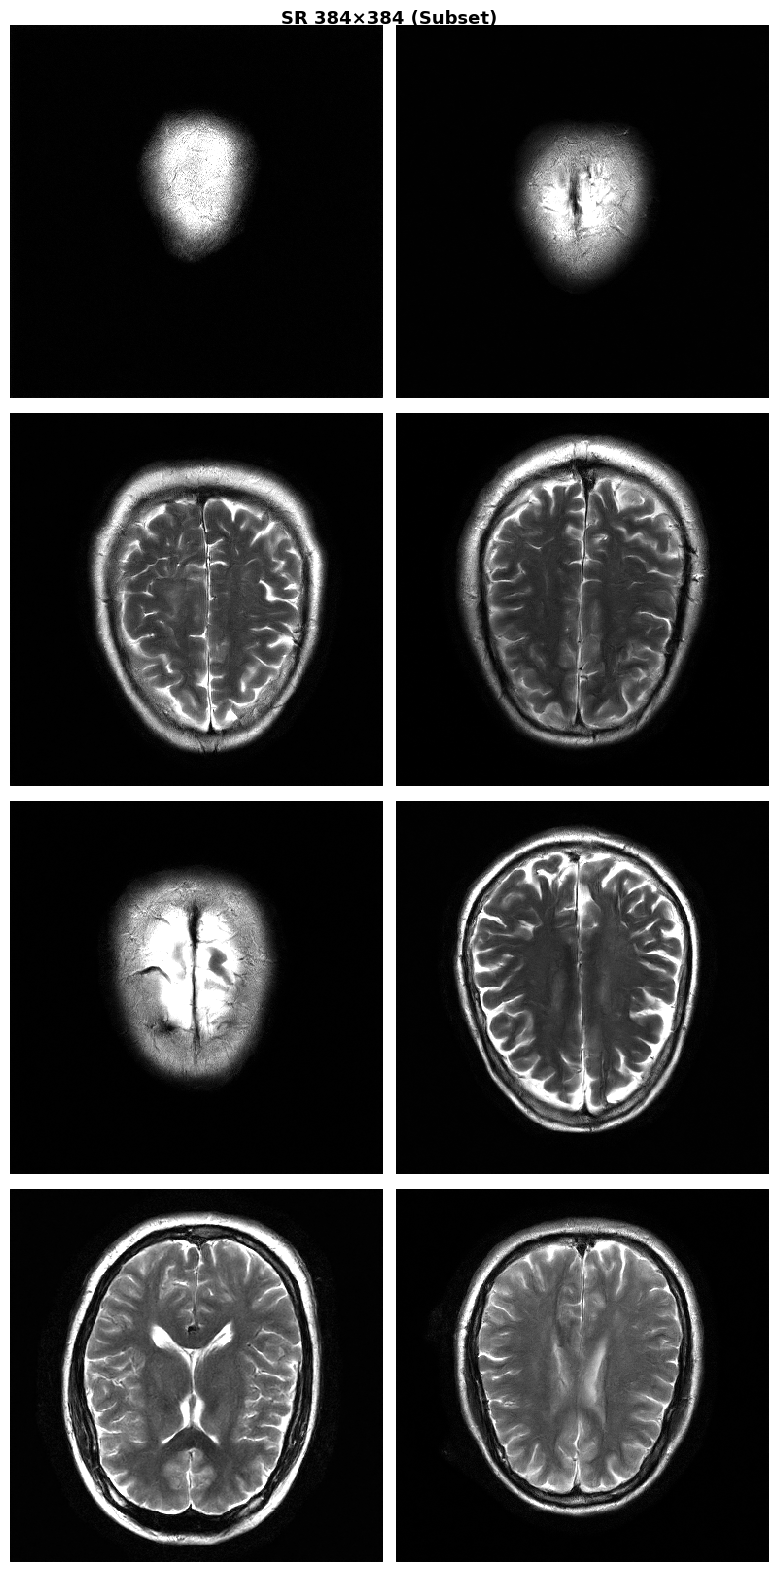

In [13]:
if sr_384 is not None:
    mag_sr = mri_magnitude(sr_384)
    
    # 1. Select only the first 4 images to reduce clutter
    max_images = 8
    mag_sr = mag_sr[:max_images]
    
    n      = len(mag_sr)
    ncol   = 2  # Set to 2 columns for larger tiles
    nrows  = math.ceil(n / ncol)

    # 2. Increase figsize multipliers (e.g., from 1.8 to 4.0)
    fig, axes = plt.subplots(nrows, ncol,
                             figsize=(ncol * 4.0, nrows * 4.0))
    axes = np.array(axes).reshape(nrows, ncol)

    for i in range(nrows):
        for j in range(ncol):
            ax  = axes[i, j]
            ax.axis("off")
            idx = i * ncol + j
            if idx < n:
                # 3. Change interpolation to 'none' or 'nearest' to avoid blur
                ax.imshow(mag_sr[idx], cmap="gray",
                          interpolation="nearest",
                          vmin=0.0, vmax=0.6)

    fig.suptitle(f"SR 384×384 (Subset)", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()

## 9. Cascade Comparison 


Shows: **Base 96** | **NN-upsampled 384** | **EDM-SR 384**
so you can visually assess the quality boost from the SR stage.

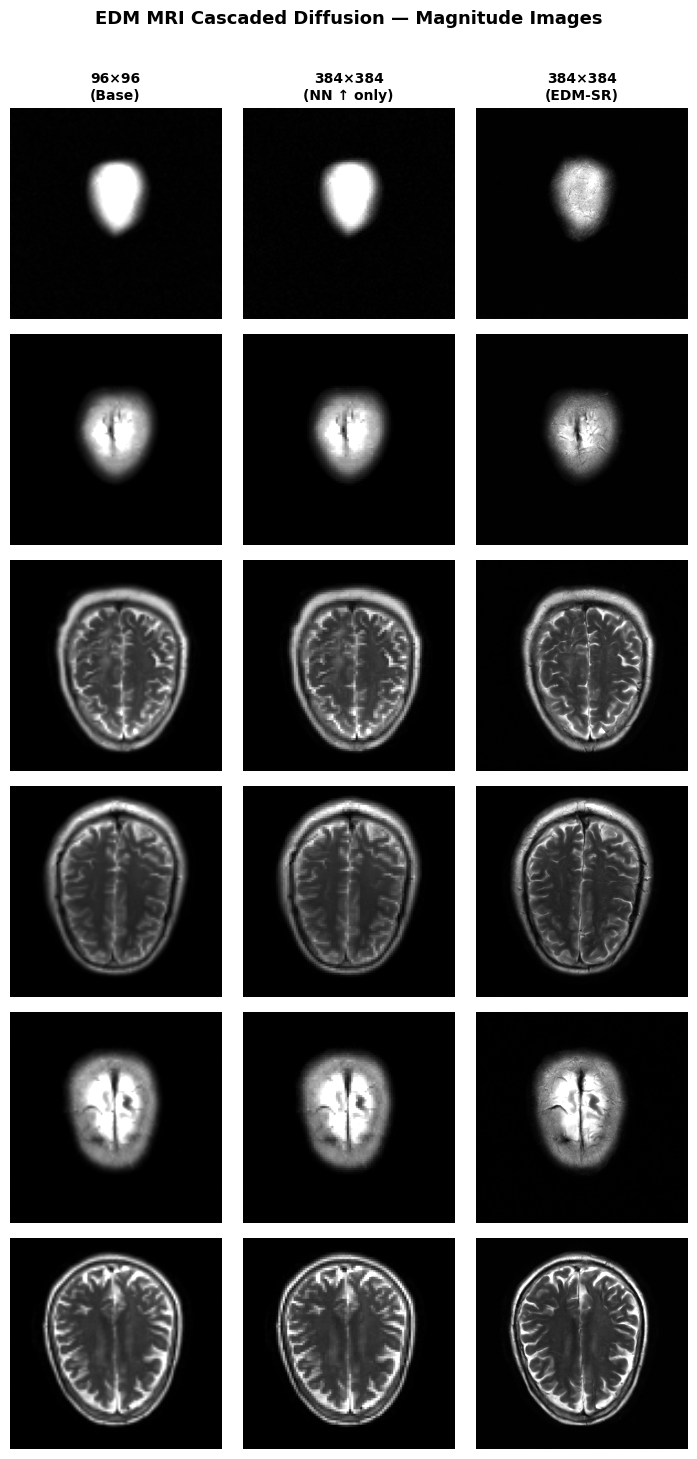

In [14]:
from collections import OrderedDict

cascade_results = OrderedDict()
cascade_results["96×96\n(Base)"] = base_96

if sr_384 is not None:
    # NN-upsampled baseline (no SR network)
    base_up384 = F.interpolate(base_96, size=384, mode="nearest")
    cascade_results["384×384\n(NN ↑ only)"] = base_up384
    cascade_results["384×384\n(EDM-SR)"]    = sr_384

show_cascade_comparison(cascade_results, n_show=min(6, NUM_SAMPLES))


## 10. Per-Channel Analysis

Inspect Real and Imaginary channels separately.

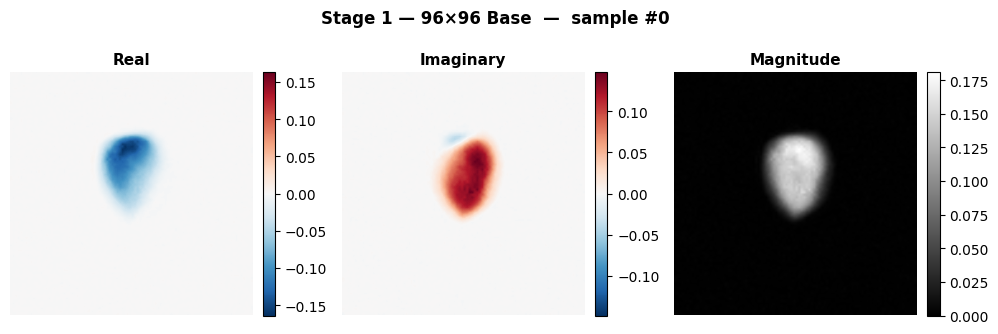

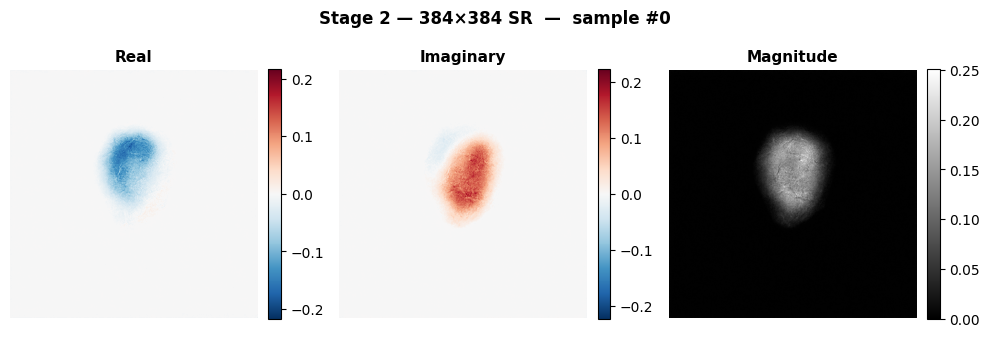

In [15]:
def show_two_channel(x: torch.Tensor, title_prefix: str, idx: int = 0, cmap: str = "RdBu_r"):
    """Plot Real, Imaginary, and Magnitude for sample `idx`."""
    re  = x[idx, 0].cpu().numpy()
    im  = x[idx, 1].cpu().numpy()
    mag = np.sqrt(re**2 + im**2)

    fig, axes = plt.subplots(1, 3, figsize=(10, 3.5))
    for ax, data, label in zip(
        axes,
        [re, im, mag],
        ["Real", "Imaginary", "Magnitude"],
    ):
        vmax = np.abs(data).max() if label != "Magnitude" else data.max()
        vmin = -vmax if label != "Magnitude" else 0
        im_plot = ax.imshow(data, cmap=cmap if label != "Magnitude" else "gray",
                            vmin=vmin, vmax=vmax, interpolation="bilinear")
        plt.colorbar(im_plot, ax=ax, fraction=0.046, pad=0.04)
        ax.set_title(f"{label}", fontsize=11, fontweight="bold")
        ax.axis("off")
    fig.suptitle(f"{title_prefix}  —  sample #{idx}", fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.show()

# Show channel breakdown for sample 0 at both resolutions
SAMPLE_IDX = 0
show_two_channel(base_96,  "Stage 1 — 96×96 Base", idx=SAMPLE_IDX)
if sr_384 is not None:
    show_two_channel(sr_384, "Stage 2 — 384×384 SR", idx=SAMPLE_IDX)


## 11. Save Samples

In [16]:
import torch

save_dir = os.path.join(PROJECT_ROOT, "samples", "edm_mri_cascade_notebook")
os.makedirs(save_dir, exist_ok=True)

def save_stage(tensor: torch.Tensor, subdir: str):
    """Save 2ch tensors as .pt and magnitude as 8-bit PNG."""
    out = os.path.join(save_dir, subdir)
    os.makedirs(out, exist_ok=True)
    mag_np = mri_magnitude(tensor)                    # (N, H, W) in [0, 1]
    for i in range(tensor.shape[0]):
        # Save raw 2ch tensor
        torch.save(tensor[i].cpu(), os.path.join(out, f"sample_{i:04d}_2ch.pt"))
        # Save magnitude PNG (uint8)
        mag_uint8 = (mag_np[i] * 255).clip(0, 255).astype(np.uint8)
        from PIL import Image
        Image.fromarray(mag_uint8, mode="L").save(os.path.join(out, f"sample_{i:04d}_mag.png"))
    print(f"  Saved {tensor.shape[0]} samples → {out}/")

save_stage(base_96, "96x96")
if sr_384 is not None:
    save_stage(sr_384, "384x384")

print(f"\n✓ All samples saved to: {save_dir}")


/tmp/ipykernel_1843912/2338820594.py:17: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  Image.fromarray(mag_uint8, mode="L").save(os.path.join(out, f"sample_{i:04d}_mag.png"))


  Saved 8 samples → /CBIG-Standard-ECE/Sahil/mri_cascaded_diffusion/samples/edm_mri_cascade_notebook/96x96/
  Saved 8 samples → /CBIG-Standard-ECE/Sahil/mri_cascaded_diffusion/samples/edm_mri_cascade_notebook/384x384/

✓ All samples saved to: /CBIG-Standard-ECE/Sahil/mri_cascaded_diffusion/samples/edm_mri_cascade_notebook


## 12. Training Loss Curves

Plot the `Loss/loss` metric from `stats.jsonl` for both checkpoints.

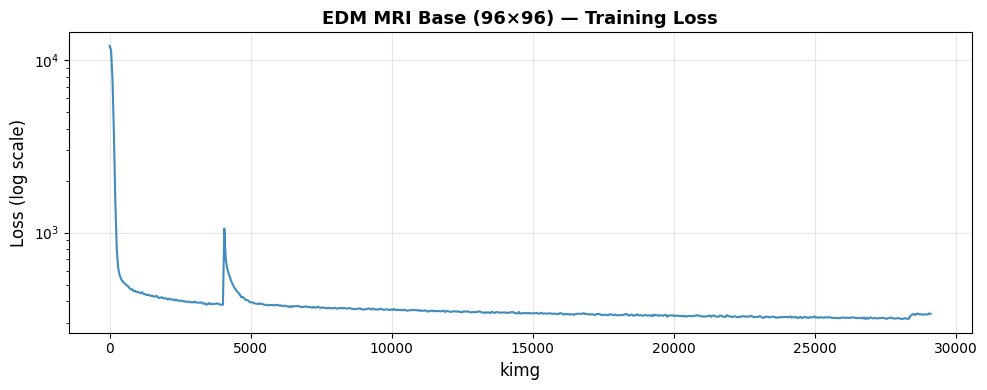

  → latest: kimg=29101,  loss=338.15993


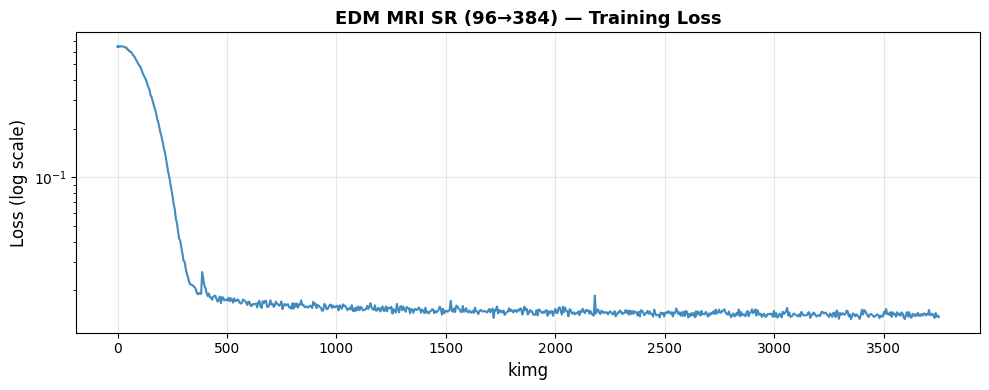

  → latest: kimg=3752,  loss=0.01366


In [17]:
def plot_training_loss(stats_path: str, title: str = "Training Loss"):
    """Parse stats.jsonl and plot the training loss curve."""
    if not os.path.exists(stats_path):
        print(f"Not found: {stats_path}")
        return
    kimg_vals, loss_vals = [], []
    with open(stats_path) as f:
        for line in f:
            try:
                d = json.loads(line)
                if "Progress/kimg" in d and "Loss/loss" in d:
                    kimg_vals.append(d["Progress/kimg"]["mean"])
                    loss_vals.append(d["Loss/loss"]["mean"])
            except Exception:
                pass
    if not kimg_vals:
        print(f"  (no data in {stats_path})")
        return
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(kimg_vals, loss_vals, linewidth=1.5, alpha=0.85)
    ax.set_xlabel("kimg", fontsize=12)
    ax.set_ylabel("Loss (log scale)", fontsize=12)
    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.set_yscale("log")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    print(f"  → latest: kimg={kimg_vals[-1]:.0f},  loss={loss_vals[-1]:.5f}")

# ── Base model ────────────────────────────────────────────────────────────────
base_stats = glob.glob(os.path.join(PROJECT_ROOT, "checkpoints/edm_mri_base_96/stats.jsonl"))
if base_stats:
    plot_training_loss(base_stats[-1], "EDM MRI Base (96×96) — Training Loss")
else:
    print("No base stats.jsonl found.")

# ── SR model ──────────────────────────────────────────────────────────────────
sr_stats = glob.glob(os.path.join(PROJECT_ROOT, "checkpoints/edm_mri_sr_384/stats.jsonl"))
if sr_stats:
    plot_training_loss(sr_stats[-1], "EDM MRI SR (96→384) — Training Loss")
else:
    print("No SR stats.jsonl found.")
